# Deep Agents overview
- Build agents that can plan, use subagents, and leverage file systems for complex tasks

- deepagents is a standalone library for building agents that can tackle complex, multi-step tasks. Built on LangGraph and inspired by applications like Claude Code, Deep Research, and Manus, deep agents come with planning capabilities, file systems for context management, and the ability to spawn subagents.

### When to use deep agents
- Use deep agents when you need agents that can:

  - Handle complex, multi-step tasks that require planning and decomposition
  - Manage large amounts of context through file system tools
  - Delegate work to specialized subagents for context isolation
  - Persist memory across conversations and threads

In [1]:
### Basic deep agent

import os
from dotenv import load_dotenv
load_dotenv()

os.environ["GROQ_API_KEY"]=os.getenv("GROQ_API_KEY")
os.environ["TAVILY_API_KEY"]=os.getenv("TAVILY_API_KEY")

In [28]:
from typing import Literal
from tavily import TavilyClient
tavily_client = TavilyClient(api_key=os.getenv("TAVILY_API_KEY"))

def web_search(query:str, max_results:int=2, 
topic:Literal["general", "sports", "news", "finance"]="general", include_raw_content:bool=False):
    """Run a web search"""
    return tavily_client.search(query=query, max_results=max_results, include_raw_content=False, topic=topic)

In [29]:
web_search("What is Deep Agent?", max_results=5)

{'query': 'What is Deep Agent?',
 'follow_up_questions': None,
 'answer': None,
 'images': [],
 'results': [{'url': 'https://www.nvidia.com/en-us/glossary/deep-agents',
   'title': 'What Is a Deep Agent? | NVIDIA',
   'content': '1. Glossary\n2. Deep Agents\n\n# What Are Deep Agents?\n\nDeep agents are AI agents designed for complex, long-running work. They combine explicit planning, persistent memory, tool execution, reusable skills, and subagent delegation to decompose tasks, track progress, and act autonomously over time.\n\n How It Works\n Role of Subagents\n Deep vs. Shallow Agents\n Use Cases\n Benefits\n Challenges and Solutions\n Next Steps [...] Unlike “shallow” agents, which are limited to clearly defined use cases like report generation or retrieval-augmented generation (RAG), deep agents represent the next iteration for AI agents that enable generalized, long-running tasks. [...] Within a deep agent, a subagent is a specialized, isolated worker that executes a delegated sub

In [30]:
from langchain.chat_models import init_chat_model
model = init_chat_model("groq:openai/gpt-oss-20b")
model

ChatGroq(metadata={'lc_versions': {'langchain-core': '1.6.6', 'langchain': '1.4.3'}}, profile={'name': 'GPT OSS 20B', 'release_date': '2025-08-05', 'last_updated': '2026-05-27', 'open_weights': True, 'max_input_tokens': 131072, 'max_output_tokens': 65536, 'text_inputs': True, 'image_inputs': False, 'audio_inputs': False, 'video_inputs': False, 'text_outputs': True, 'image_outputs': False, 'audio_outputs': False, 'video_outputs': False, 'reasoning_output': True, 'tool_calling': True, 'structured_output': True, 'attachment': False, 'temperature': True}, client=<groq.resources.chat.completions.Completions object at 0x000001EDF9D7AE70>, async_client=<groq.resources.chat.completions.AsyncCompletions object at 0x000001EDF9D7B770>, model_name='openai/gpt-oss-20b', model_kwargs={}, groq_api_key=SecretStr('**********'))

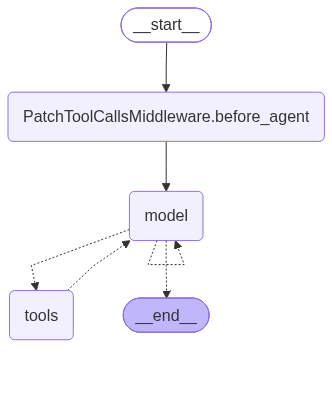

In [31]:
### Create a deep agent
### prompt


## agent

from deepagents import create_deep_agent
deepagent = create_deep_agent(
    model=model,
    tools=[web_search],
    system_prompt="Act as a researcher"
)

deepagent

In [32]:
result = deepagent.invoke({"messages": [{"role": "user", "content": "What is deepagent?"}]})
result

{'messages': [HumanMessage(content='What is deepagent?', additional_kwargs={}, response_metadata={}, id='e2899a0a-0343-4e83-b6fc-88a9af74a1ae'),
  AIMessage(content='', additional_kwargs={'reasoning_content': 'We need to answer: "What is deepagent?" The user didn\'t specify context. Could be a software, a library, an agent system. We need to research. Use web search.', 'tool_calls': [{'id': 'fc_d888af3c-a778-4d76-b924-a96b768ea589', 'function': {'arguments': '{"max_results":10,"query":"deepagent","topic":"general"}', 'name': 'web_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 72, 'prompt_tokens': 1979, 'total_tokens': 2051, 'completion_time': 0.075654927, 'completion_tokens_details': {'reasoning_tokens': 39}, 'prompt_time': 0.098564837, 'prompt_tokens_details': None, 'queue_time': 0.208632626, 'total_time': 0.174219764}, 'model_name': 'openai/gpt-oss-20b', 'system_fingerprint': 'fp_a12402de73', 'service_tier': 'on_demand', 'finish_reason': 'too

In [33]:
result["messages"][-1].content

'**DeepAgent** is a modern AI‑agent framework that aims to make large language models (LLMs) capable of tackling *long‑horizon, open‑ended* tasks in a way that feels more natural and less rigid than traditional “think‑act‑observe” loops.\n\n---\n\n### 1. Core Idea  \n- **End‑to‑end reasoning** – Instead of a fixed “plan → act → observe” pipeline, the agent reasons in a single continuous stream, deciding *when* to plan, *what* tool to use, and *how* to act.  \n- **Dynamic tool discovery** – The agent can discover and load new tools on‑the‑fly, rather than being handed a fixed toolbox.  \n- **Scalable memory** – Past interactions are compressed into structured “episodic,” “working,” and “tool” memories so the agent can keep track of long‑term goals without blowing up the context window.  \n\n### 2. Typical Implementations  \n| Project | Key Features | Example Use‑case |\n|---------|--------------|-----------------|\n| **RUC‑NLPIR DeepAgent** | Reinforcement‑learning‑based tool selection 

In [35]:
result['files']

{}